In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, f_oneway

In [6]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya.csv")
nigeria = pd.read_csv("../data/nigeria.csv")
tanzania = pd.read_csv("../data/tanzania.csv")
sudan = pd.read_csv("../data/sudan.csv")

In [7]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"
tanzania["Country"] = "Tanzania"
sudan["Country"] = "Sudan"

In [8]:
df = pd.concat([ethiopia, kenya, nigeria, tanzania, sudan])

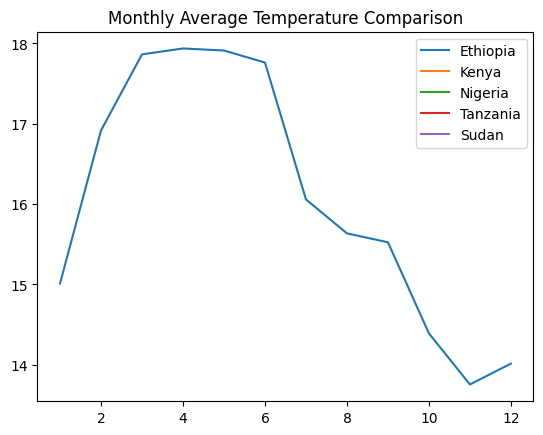

In [9]:
monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()

for country in df["Country"].unique():
    temp = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(temp["Month"], temp["T2M"], label=country)

plt.title("Monthly Average Temperature Comparison")
plt.legend()
plt.show()

In [10]:
df.groupby("Country")["T2M"].agg(["mean", "median", "std"])

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


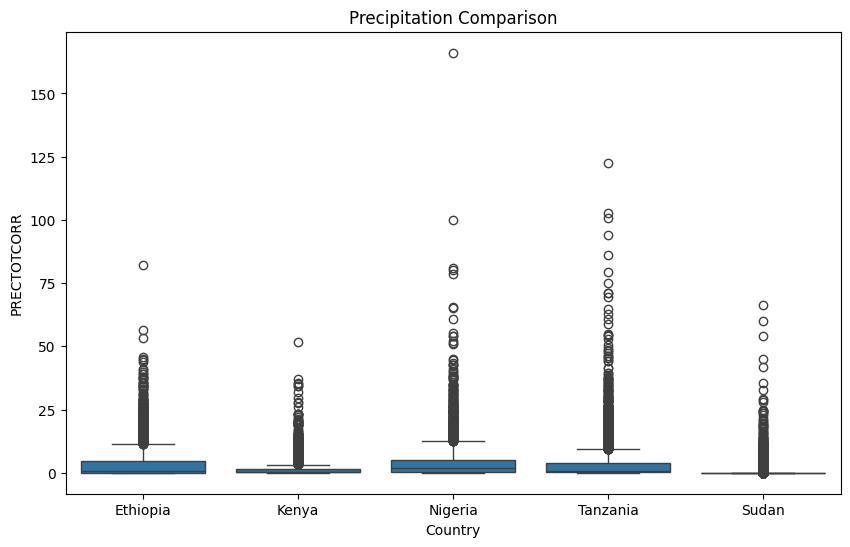

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Comparison")
plt.show()

In [12]:
df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


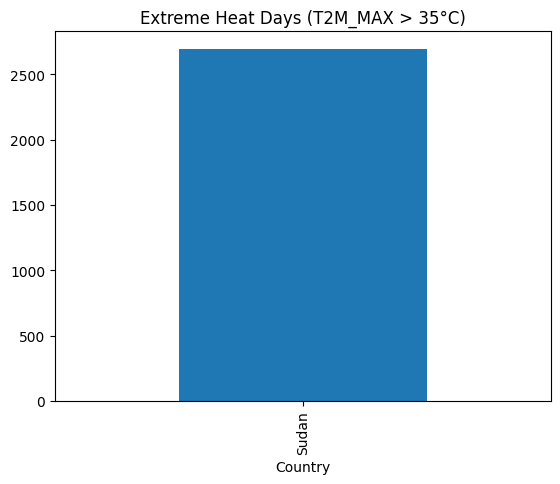

In [13]:
heat = df[df["T2M_MAX"] > 35].groupby("Country").size()

heat.plot(kind="bar")
plt.title("Extreme Heat Days (T2M_MAX > 35°C)")
plt.show()

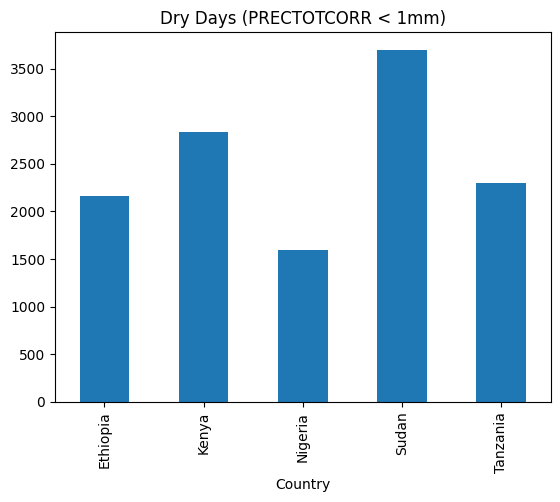

In [14]:
dry = df[df["PRECTOTCORR"] < 1].groupby("Country").size()

dry.plot(kind="bar")
plt.title("Dry Days (PRECTOTCORR < 1mm)")
plt.show()

In [15]:
groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]

f_stat, p_val = f_oneway(*groups)

print("ANOVA p-value:", p_val)

ANOVA p-value: 0.0


In [16]:
ranking = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std"
}).sort_values("T2M", ascending=False)

ranking

,T2M,PRECTOTCORR
Country,,
Sudan,28.759007,3.057672
Tanzania,26.802422,8.003947
Nigeria,26.656928,7.266742
Kenya,20.427600,3.180228
Ethiopia,16.068500,6.289061


In [17]:
summary = df.groupby("Country").agg({
    "T2M": ["mean", "std"],
    "PRECTOTCORR": ["mean", "std"]
})

summary

T2M           PRECTOTCORR          
               mean       std        mean       std
Country                                            
Ethiopia  16.068500  1.898050    3.633795  6.289061
Kenya     20.427600  1.440824    1.468162  3.180228
Nigeria   26.656928  1.123335    4.213914  7.266742
Sudan     28.759007  4.681305    0.643875  3.057672
Tanzania  26.802422  1.325388    3.740256  8.003947

1. Data Integration
Load cleaned datasets for all five countries
Combine them into a single dataset for comparison
Ensure all columns are consistent across countries

2. Temperature Analysis
Compare monthly average temperature (T2M) across all countries
Calculate mean, median, and standard deviation for each country
Identify which countries are generally hotter or warming faster over time

3. Rainfall Analysis
Compare precipitation (PRECTOTCORR) across countries
Use summary statistics and boxplots to analyze variability
Identify countries with unstable or irregular rainfall patterns

4. Extreme Weather Events
Count extreme heat days (T2M_MAX > 35°C) for each country
Count dry days (PRECTOTCORR < 1 mm) for each country
Compare frequency of climate extremes across countries

5. Statistical Testing
Apply ANOVA (or similar test) to check if temperature differences between countries are statistically significant
Interpret p-values in plain language

6. Climate Vulnerability Ranking
Create a ranking of countries based on:
temperature levels and variability
rainfall instability
extreme heat frequency
drought frequency
Rank countries from most vulnerable to least vulnerable using evidence from the data

7. COP32 Insights (Policy Takeaways)
Which country is warming the fastest
Which country has the most unstable rainfall patterns
Where combined heat and drought stress is highest
How Ethiopia compares to neighboring countries
Which country should be prioritized for climate finance and why the data supports it